Projet — Prédiction du succès d’une
campagne marketing bancaire

Contexte
Une banque lance régulièrement des campagnes téléphoniques pour proposer un produit
d’épargne à ses clients. Elle souhaite :
- comprendre quels profils répondent positivement
- identifier les facteurs influençant la décision
- prédire quels clients contacter pour optimiser les coûts.

In [3]:
# Installation de Missingno
!pip install missingno

In [4]:
import pandas as pd   
from pathlib import Path
import numpy as np          
import matplotlib.pyplot as plt 
import missingno as msno    
import seaborn as sns       
from sklearn.experimental import enable_iterative_imputer  
from sklearn.impute import MissingIndicator   
from sklearn.impute import KNNImputer        
from sklearn.impute import SimpleImputer      
from sklearn.impute import IterativeImputer  
from scipy.stats import zscore
from sklearn.ensemble import IsolationForest

## Description des imports

### Manipulation des données
- **`pandas`** : Manipulation et analyse des données sous forme de tableaux (DataFrame)
- **`numpy`** : Calculs mathématiques et opérations sur les tableaux numériques
- **`pathlib.Path`** : Gestion des chemins de fichiers de façon portable (fonctionne sur tous les OS)

### Visualisation
- **`matplotlib.pyplot`** : Création de graphiques de base (histogrammes, courbes, boxplots...)
- **`seaborn`** : Visualisations statistiques avancées et esthétiques (heatmaps, boxplots...)
- **`missingno`** : Visualisation spécialisée des valeurs manquantes (matrix, heatmap, barplot)

### Détection des valeurs aberrantes
- **`scipy.stats.zscore`** : Calcul du Z-score pour détecter les outliers statistiques
- **`sklearn.ensemble.IsolationForest`** : Détection d'outliers multivariés par isolation des anomalies

### Traitement des valeurs manquantes
- **`SimpleImputer`** : Remplace les valeurs manquantes par la moyenne, médiane ou valeur la plus fréquente
- **`KNNImputer`** : Remplace les valeurs manquantes en se basant sur les K voisins les plus proches
- **`IterativeImputer`** : Imputation avancée en modélisant chaque variable manquante en fonction des autres
- **`MissingIndicator`** : Crée une colonne binaire pour signaler si une valeur était manquante
- **`enable_iterative_imputer`** : Active l'IterativeImputer (encore expérimental dans sklearn)

In [5]:
df = pd.read_csv("data/bank-full.csv", sep=';') 
df.head(10)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
5,35,management,married,tertiary,no,231,yes,no,unknown,5,may,139,1,-1,0,unknown,no
6,28,management,single,tertiary,no,447,yes,yes,unknown,5,may,217,1,-1,0,unknown,no
7,42,entrepreneur,divorced,tertiary,yes,2,yes,no,unknown,5,may,380,1,-1,0,unknown,no
8,58,retired,married,primary,no,121,yes,no,unknown,5,may,50,1,-1,0,unknown,no
9,43,technician,single,secondary,no,593,yes,no,unknown,5,may,55,1,-1,0,unknown,no


### objectif de l'étude et formalisation des hypothèses
L'objectif de l'étude est de faire une classification des clients de la banque afin de prédire leur sousciption à un dépôt à terme.

### Hypothèses 
**Hypothèse 1** : L'âge influence la souscription
Plus la variable **`age`** est élevée plus le client est susceptible de souscrire à un dépot à terme, c'est-à-dire que la variable cible **`y`** égal à 'oui'.

**Hypothèse 2** : Le succès d'une campagne précédente prédit la souscription
Les clients ayant répondu positivement lors d'une campagne 
précédente (**`poutcome`** = 'succès') ont significativement plus 
de chances de souscrire un dépôt à terme lors de cette campagne (**`y`** = 'oui')

**Hypothèse 3** : La durée de l'appel est un indicateur clé
Plus la durée de l'appel (**`duration`**) est longue, plus le client 
est engagé dans la conversation et donc plus il est susceptible 
de souscrire un dépôt à terme (**`y`** = 'oui)


Caractéristiques de la dataset

## 📋 Description des variables

### 👤 Données personnelles du client
- **`age`** *(numérique)* : Âge du client
- **`job`** *(catégorielle)* : Métier du client (admin, ouvrier, technicien...)
- **`marital`** *(catégorielle)* : Situation maritale (marié, célibataire, divorcé)
- **`education`** *(catégorielle)* : Niveau d'éducation (primaire, secondaire, tertiaire)
- **`default`** *(catégorielle)* : A-t-il un crédit en défaut ? (oui/non)
- **`balance`** *(numérique)* : Solde annuel moyen en euros
- **`housing`** *(catégorielle)* : A-t-il un prêt immobilier ? (oui/non)
- **`loan`** *(catégorielle)* : A-t-il un prêt personnel ? (oui/non)

### 📞 Données du dernier contact
- **`contact`** *(catégorielle)* : Type de contact (téléphone fixe, mobile)
- **`day`** *(numérique)* : Jour du mois du dernier contact
- **`month`** *(catégorielle)* : Mois du dernier contact
- **`duration`** *(numérique)* : Durée du dernier appel en secondes

### 📊 Autres attributs
- **`campaign`** *(numérique)* : Nombre de contacts effectués durant cette campagne
- **`pdays`** *(numérique)* : Jours depuis le dernier contact d'une campagne précédente (-1 = jamais contacté)
- **`previous`** *(numérique)* : Nombre de contacts effectués avant cette campagne
- **`poutcome`** *(catégorielle)* : Résultat de la campagne précédente (succès, échec, inconnu)

### 🎯 Variable cible
- **`y`** *(binaire)* : Le client a-t-il souscrit un dépôt à terme ? (oui/non)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


La dateset comporte 45221 lignes de données  et de 17 colonnes ;
Les colonnes sont principalement de deux types : int64 (7 colonnnes) pour les données quantitatives et object(10 colonnes) pour les données qualitatives


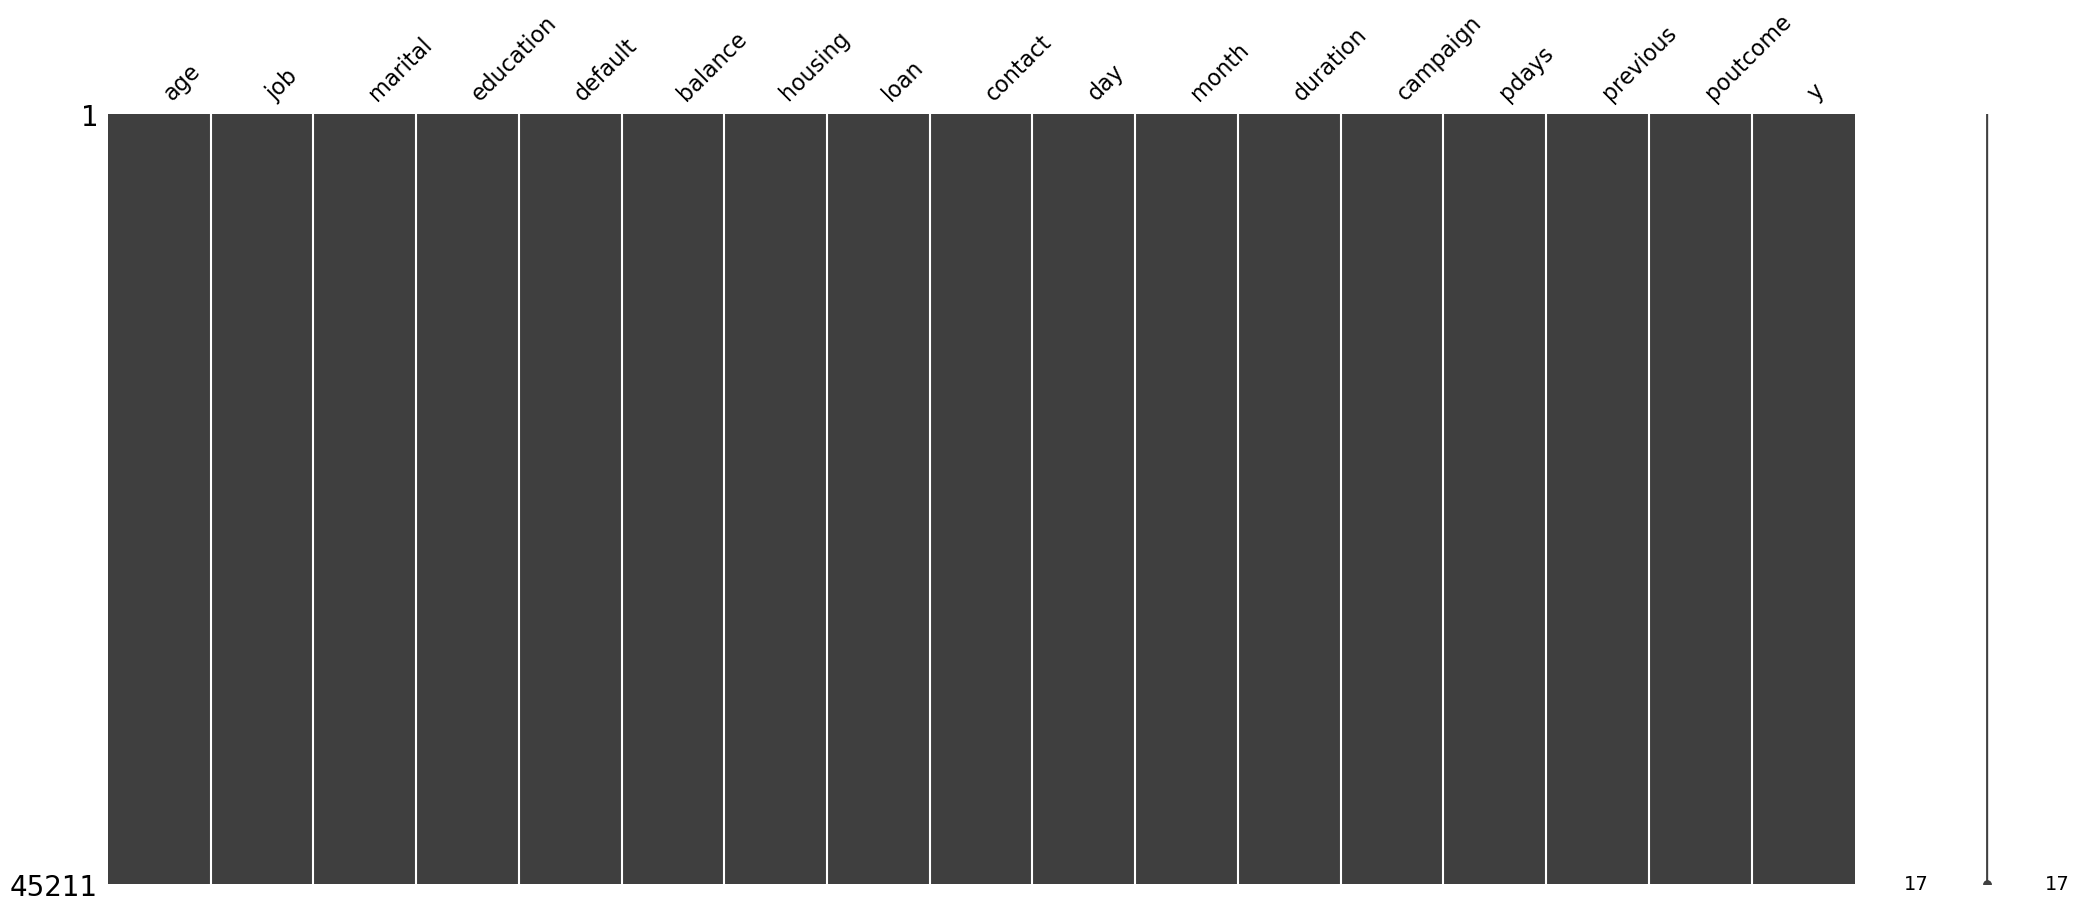

In [7]:
msno.matrix(df)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

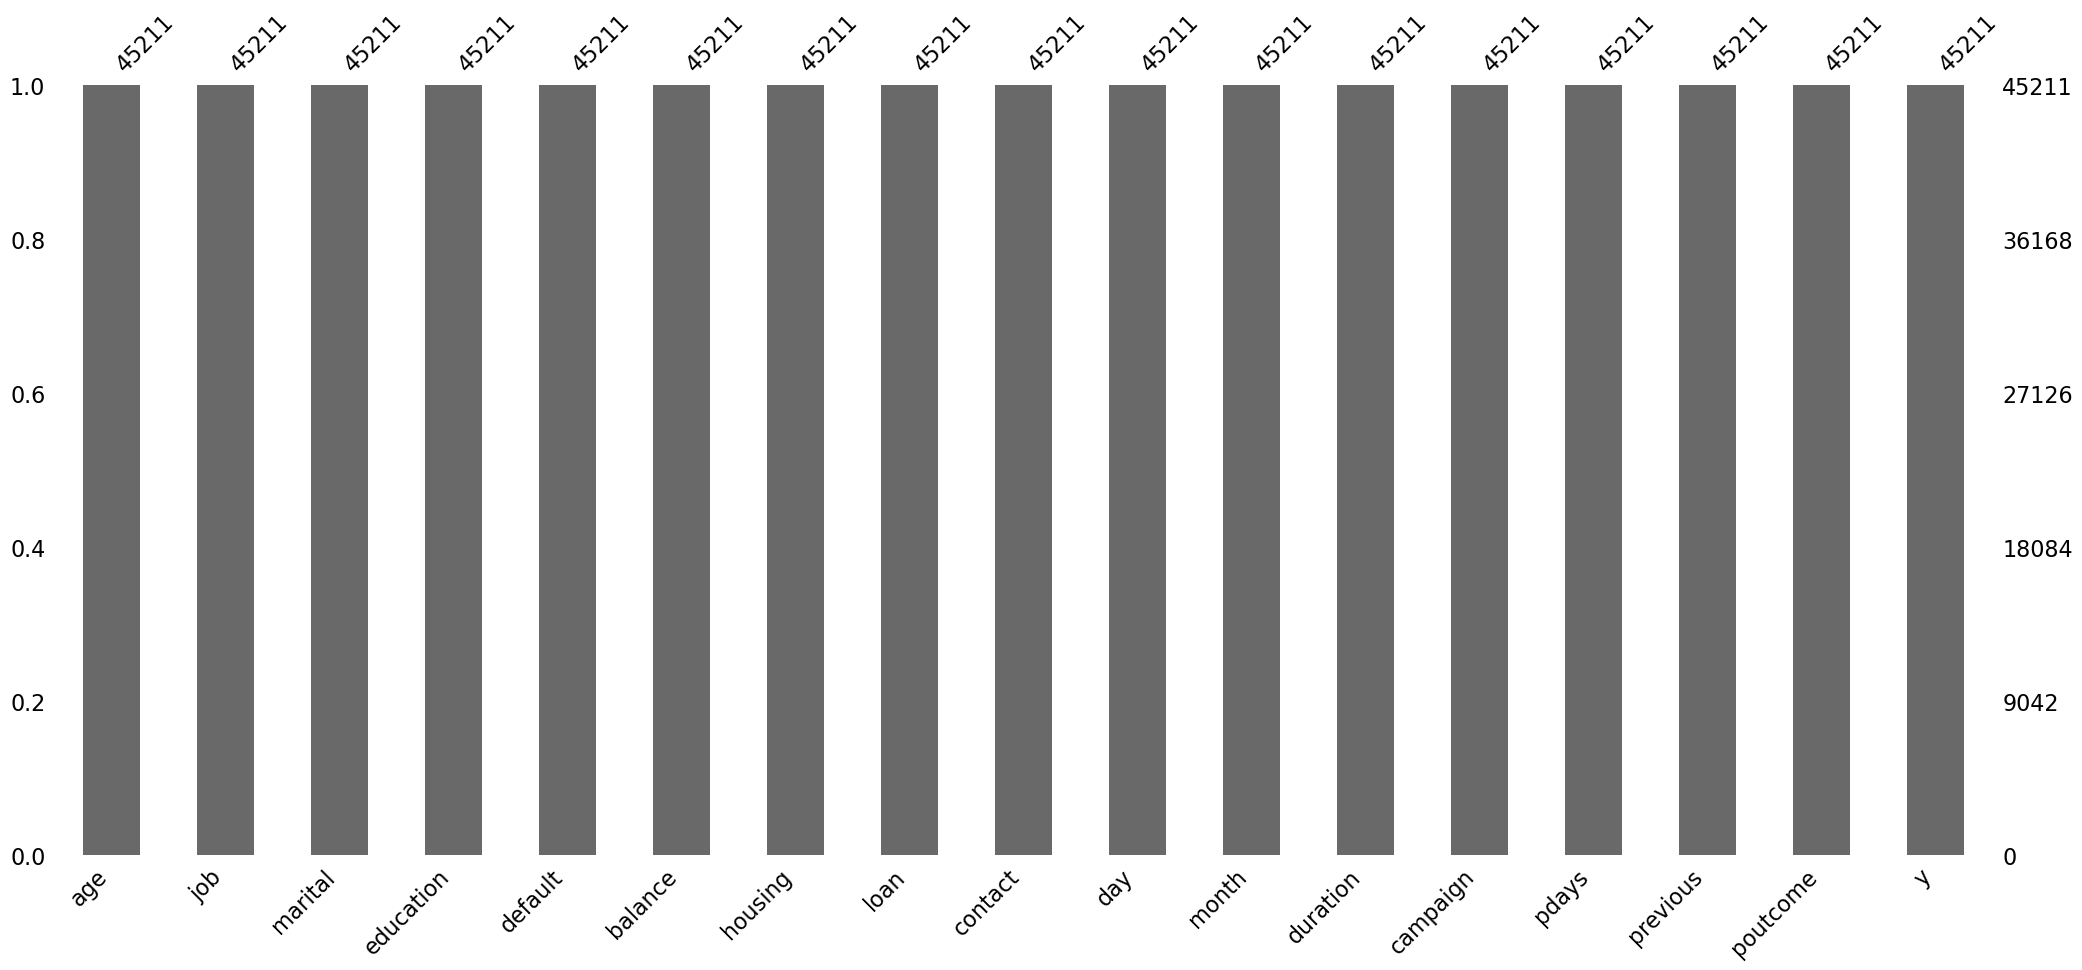

In [8]:
msno.bar(df)
plt.show

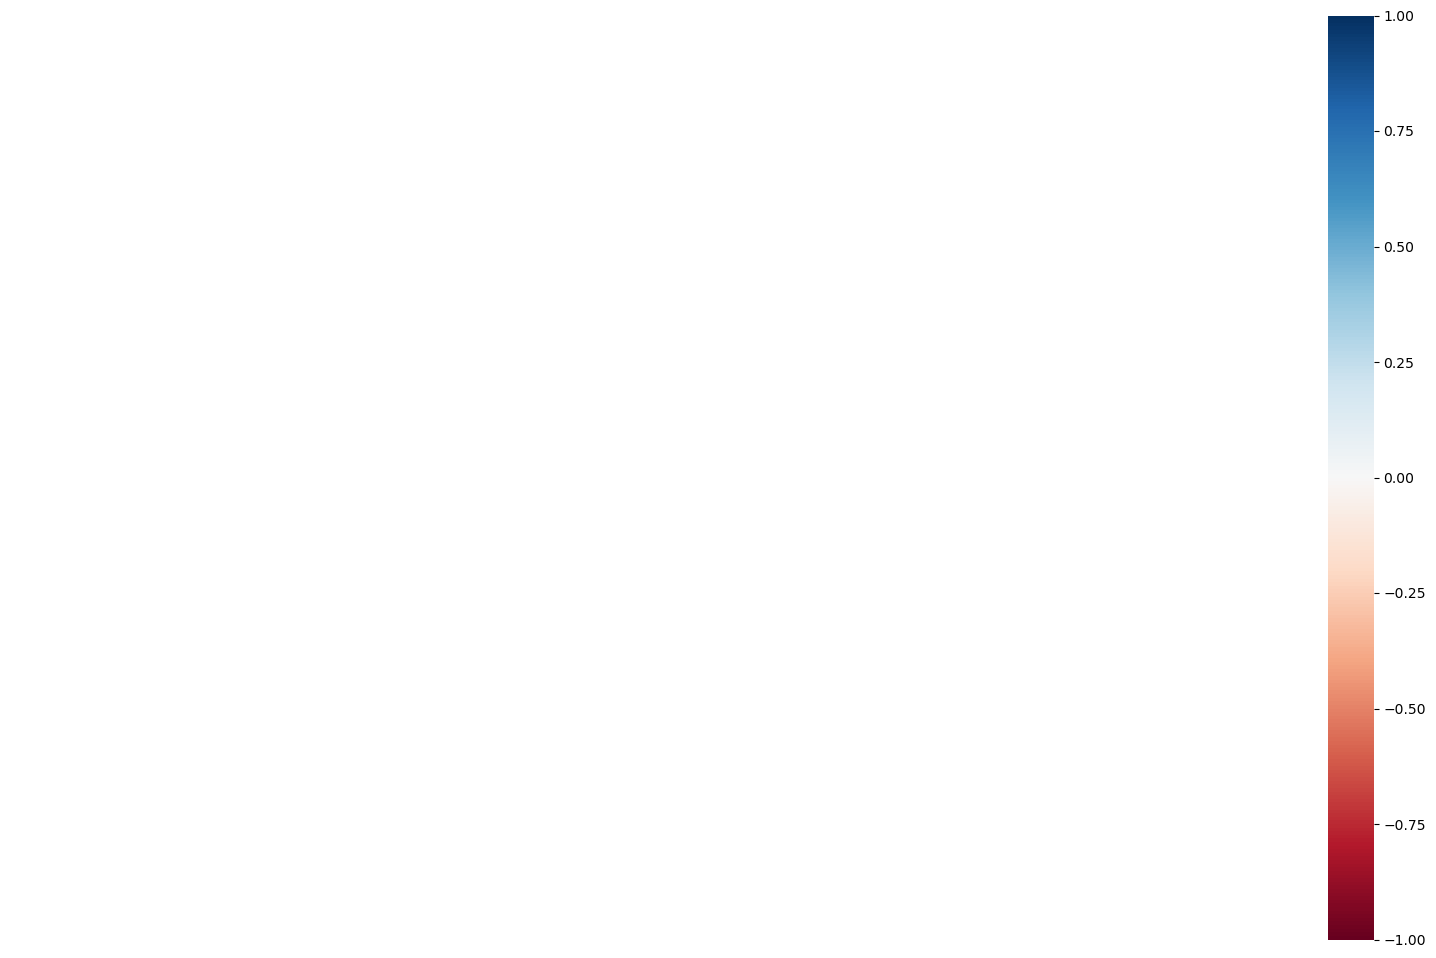

In [9]:
import warnings
warnings.filterwarnings('ignore')
msno.heatmap(df)
plt.show()

In [10]:
missing_value = df.isnull().sum()
missing_percent = (missing_value / len(df)) * 100
missing_table = pd.DataFrame({'Missing_value':missing_value, 'Missing_percent':missing_percent})
print(missing_table)

           Missing_value  Missing_percent
age                    0              0.0
job                    0              0.0
marital                0              0.0
education              0              0.0
default                0              0.0
balance                0              0.0
housing                0              0.0
loan                   0              0.0
contact                0              0.0
day                    0              0.0
month                  0              0.0
duration               0              0.0
campaign               0              0.0
pdays                  0              0.0
previous               0              0.0
poutcome               0              0.0
y                      0              0.0


Desription de la dataset

In [12]:
df.describe(include =("all"))

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
count,45211.000000,45211,45211,45211,45211,45211.000000,45211,45211,45211,45211.000000,45211,45211.000000,45211.000000,45211.000000,45211.000000,45211,45211
unique,NaN,12,3,4,2,NaN,2,2,3,NaN,12,NaN,NaN,NaN,NaN,4,2
top,NaN,blue-collar,married,secondary,no,NaN,yes,no,cellular,NaN,may,NaN,NaN,NaN,NaN,unknown,no
freq,NaN,9732,27214,23202,44396,NaN,25130,37967,29285,NaN,13766,NaN,NaN,NaN,NaN,36959,39922
mean,40.936210,NaN,NaN,NaN,NaN,1362.272058,NaN,NaN,NaN,15.806419,NaN,258.163080,2.763841,40.197828,0.580323,NaN,NaN
std,10.618762,NaN,NaN,NaN,NaN,3044.765829,NaN,NaN,NaN,8.322476,NaN,257.527812,3.098021,100.128746,2.303441,NaN,NaN
min,18.000000,NaN,NaN,NaN,NaN,-8019.000000,NaN,NaN,NaN,1.000000,NaN,0.000000,1.000000,-1.000000,0.000000,NaN,NaN
25%,33.000000,NaN,NaN,NaN,NaN,72.000000,NaN,NaN,NaN,8.000000,NaN,103.000000,1.000000,-1.000000,0.000000,NaN,NaN
50%,39.000000,NaN,NaN,NaN,NaN,448.000000,NaN,NaN,NaN,16.000000,NaN,180.000000,2.000000,-1.000000,0.000000,NaN,NaN
75%,48.000000,NaN,NaN,NaN,NaN,1428.000000,NaN,NaN,NaN,21.000000,NaN,319.000000,3.000000,-1.000000,0.000000,NaN,NaN


### Identification graphique des outliers

In [15]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Numériques :", num_cols)
print("Catégorielles :", cat_cols)

Numériques : ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Catégorielles : ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']


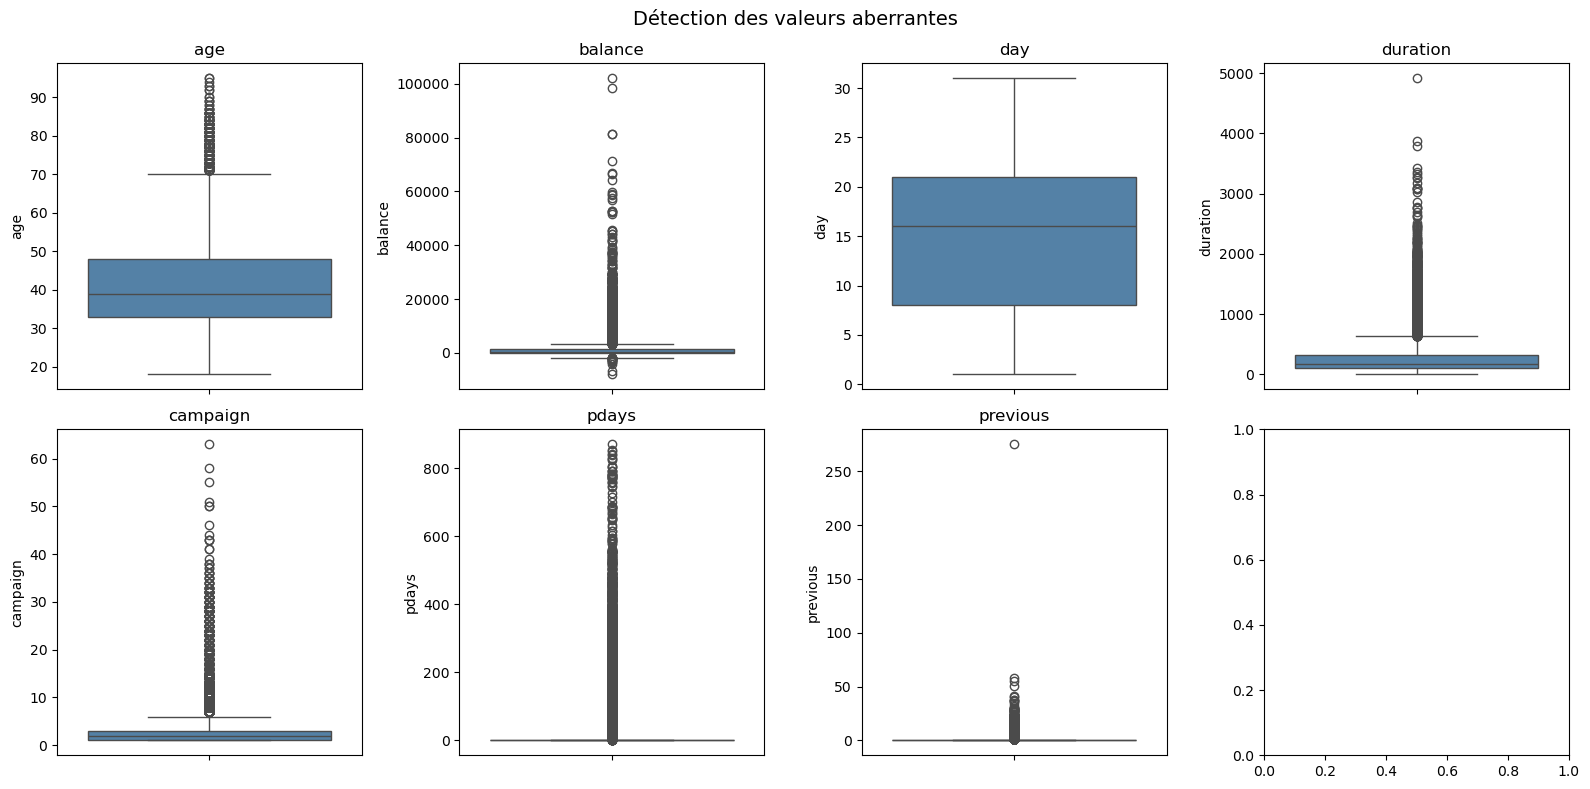

In [16]:
# Visualisation des outliers avec boxplot de seaborn
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=df, y=col, ax=axes[i], color='steelblue')
    axes[i].set_title(col)

plt.suptitle("Détection des valeurs aberrantes", fontsize=14)
plt.tight_layout()
plt.show()

1. age — Acceptable

Distribution centrée entre 33 et 48 ans
Quelques outliers au-dessus de 70 ans mais c'est réaliste (des clients âgés existent)
Pas de traitement nécessaire


2. balance — Outliers importants

La boîte est écrasée vers le bas — la majorité des clients ont un solde faible
Des valeurs jusqu'à 100 000€, très peu de clients très riches
Quelques valeurs négatives (clients à découvert)
Traitement recommandé : clipper ou remplacer par la médiane


3. day — Rien d'anormal

Représente les jours du mois (1 à 31)
Distribution uniforme, aucun outlier


4. duration — Outliers significatifs

La majorité des appels durent moins de 500 secondes
Quelques appels dépassent 4000 secondes (~1h10) → suspects
Les durées à 0 sont problématiques (appels non aboutis)
Traitement recommandé : supprimer les durées = 0, clipper le reste


5. campaign — Outliers extrêmes

La plupart des clients ont été contactés 2 à 3 fois
Des clients contactés jusqu'à 60 fois → clairement aberrant
Traitement recommandé : clipper à 10 contacts maximum


6. pdays — Distribution très bizarre

Représente les jours depuis le dernier contact
Deux groupes distincts : 0 et 800+ → valeur -1 utilisée pour "jamais contacté"
Traitement recommandé : créer une variable binaire contacté_avant (oui/non)


7. previous — Outliers

Majorité à 0 (jamais contacté avant)
Quelques valeurs à 250 → aberrant
Traitement recommandé : clipper

### Identification des outliers univariées par la methode IQR

In [31]:
# Detection des valeurs abbérrantes par IQR
def detect_outlier_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_born = Q1 - 1.5 * IQR
    upper_born = Q1 + 1.5 * IQR
    return [(data[column] < lower_born), (data[column] > upper_born)]


# Appliquer à toutes les variables : 
for col in num_cols:
    lower, upper = detect_outlier_iqr(df, col)
    total = (lower | upper).sum()
    print(f"{col} : {total} outliers ({total/len(df)*100:.1f}%)")

age : 4900 outliers (10.8%)
balance : 8142 outliers (18.0%)
day : 5784 outliers (12.8%)
duration : 7042 outliers (15.6%)
campaign : 6119 outliers (13.5%)
pdays : 8257 outliers (18.3%)
previous : 8257 outliers (18.3%)


### Identification des outliers par la méthode de z-score

In [32]:
from scipy import stats
import numpy as np

# Méthode Z-score
def detect_outlier_zscore(data, column, seuil=3):
    z_scores = np.abs(stats.zscore(data[column]))
    return z_scores > seuil

# Comparaison IQR vs Z-score sur toutes les colonnes numériques
print("=" * 55)
print(f"{'Colonne':<12} {'IQR (outliers)':<20} {'Z-score (outliers)'}")
print("=" * 55)

for col in num_cols:
    # IQR
    lower, upper = detect_outlier_iqr(df, col)
    total_iqr = (lower | upper).sum()
    pct_iqr = total_iqr / len(df) * 100

    # Z-score
    outliers_z = detect_outlier_zscore(df, col)
    total_z = outliers_z.sum()
    pct_z = total_z / len(df) * 100

    print(f"{col:<12} {total_iqr} ({pct_iqr:.1f}%)          {total_z} ({pct_z:.1f}%)")

print("=" * 55)

Colonne      IQR (outliers)       Z-score (outliers)
age          4900 (10.8%)          381 (0.8%)
balance      8142 (18.0%)          745 (1.6%)
day          5784 (12.8%)          0 (0.0%)
duration     7042 (15.6%)          963 (2.1%)
campaign     6119 (13.5%)          840 (1.9%)
pdays        8257 (18.3%)          1723 (3.8%)
previous     8257 (18.3%)          582 (1.3%)


Observations clés
IQR détecte beaucoup plus d'outliers que Z-score — c'est normal et confirme que tes données ne suivent pas une distribution normale.
Par variable :
- age — IQR : 10.8% vs Z-score : 0.8% → grande différence, les âges extrêmes (très jeunes/très vieux) sont nombreux mais pas si éloignés de la moyenne
- balance — IQR : 18% vs Z-score : 1.6% → distribution très asymétrique, quelques clients très riches tirent la moyenne vers le haut
- day — IQR : 12.8% vs Z-score : 0% → pas de vrais outliers, juste une distribution uniforme des jours du mois, pas besoin de traitement
- duration — IQR : 15.6% vs Z-score : 2.1% → appels très longs anormaux 
- campaign — IQR : 13.5% vs Z-score : 1.9% → clients sur-contactés 
pdays et previous — IQR : 18.3% → les -1 (jamais contacté) faussent le calcul

### Matrice de corrélation

### Encodage des variables catégorielles

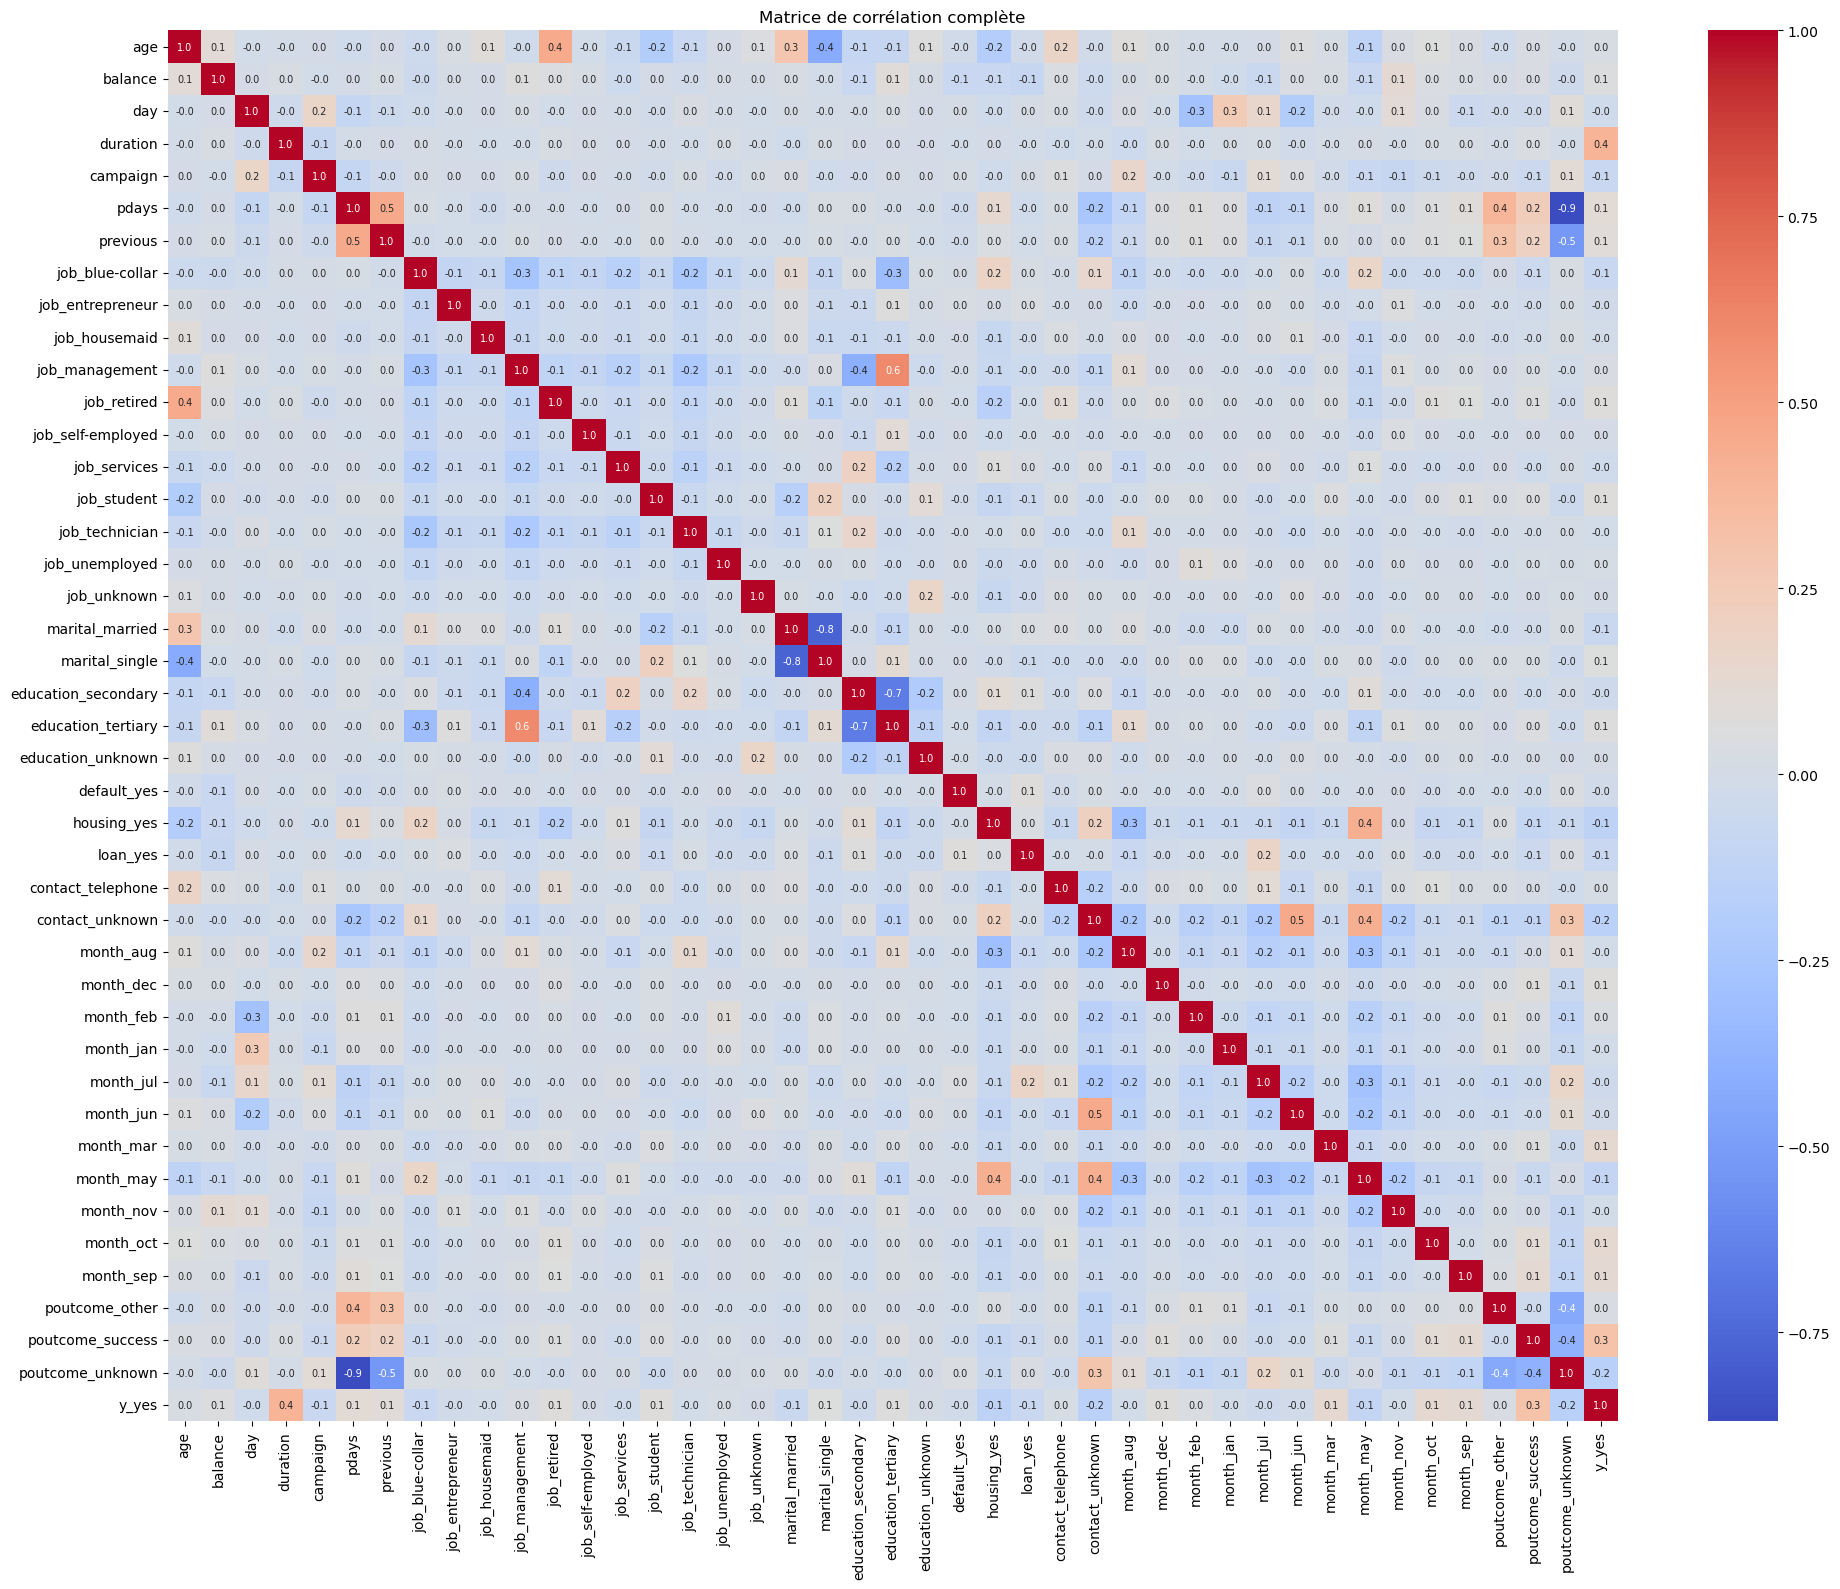

In [36]:
# Encoder toutes les variables catégorielles
df_encoded = pd.get_dummies(df, drop_first=True)

# Matrice de corrélation complète
plt.figure(figsize=(20, 16))
sns.heatmap(df_encoded.corr(), 
            annot=True, 
            cmap='coolwarm', 
            fmt='.1f',
            annot_kws={"size": 7})
plt.title("Matrice de corrélation complète")
plt.tight_layout()
plt.show()

### Interprétation de la matrice de corrélation 
🎯 **Corrélations avec la variable cible y_yes (dernière ligne)**
**Corrélations positives (rouge) — favorisent la souscription :**

-  **`duration`** → corrélation la plus forte — plus l'appel est long, plus le client souscrit, ce qui confirme notre Hypothèse 3
-  **`poutcome_success`** → campagne précédente réussie = fort prédicteur, ce qui confirme notre Hypothèse 2
-  **`contact_unknown`** → type de contact inconnu légèrement positif
-  **`month_mar/sep/oct`** → certains mois favorables

**Corrélations négatives (bleu) — défavorisent la souscription :**

-  **`poutcome_unknown`** → client jamais contacté avant = moins susceptible de souscrire
-  **`contact_telephone`** → contact par téléphone fixe moins efficace
-  **`month_may`** → mai est le pire mois pour la campagne
-  **`housing_yes`** → avoir un prêt immobilier réduit les chances


🔍 Autres corrélations intéressantes

-  **`pdays`** et  **`previous`** → fortement corrélés entre eux (logique, les deux mesurent les contacts passés)
-  **`poutcome_success`** et  **`previous`** → liés, un succès passé implique plusieurs contacts
-  **`education_tertiary`** et  **`job_management`** → les cadres ont souvent un niveau tertiaire


✅ Variables les plus importantes pour prédire **`y`**
En ordre d'importance :

-  **`duration`** 🥇
-  **`poutcome_success`** 🥈
-  **`contact_telephone`** 🥉
-  **`month_may`**
-  **`housing_yes`**

### Corrélation de Pearson & Spearman

Mesure uniquement les relationq linéaires. nous ajoutons Spearman pour capter les relations monotones, puis des scatterplots sur les variables clés

In [38]:
# Encoder y en 0/1
df['y_encoded'] = df['y'].map({'yes': 1, 'no': 0})

# Corrélations Pearson et Spearman avec y uniquement
pearson_corr = df[num_cols + ['y_encoded']].corr(method="pearson")
spearman_corr = df[num_cols + ['y_encoded']].corr(method="spearman")

corr_compare = pd.DataFrame({
    "pearson_with_target": pearson_corr["y_encoded"],
    "spearman_with_target": spearman_corr["y_encoded"]
}).sort_values("spearman_with_target", ascending=False)

corr_compare

,pearson_with_target,spearman_with_target
y_encoded,1.000000,1.000000
duration,0.394521,0.342469
previous,0.093236,0.169124
pdays,0.103621,0.154055
balance,0.052838,0.100295
age,0.025155,-0.008750
day,-0.028348,-0.029548
campaign,-0.073172,-0.084054


🔝 Variables les plus corrélées avec **`y`**
- **`duration`** → corrélation la plus forte (Pearson : 0.39, Spearman : 0.34)
C'est de loin la variable la plus prédictive — plus l'appel est long, plus le client souscrit
- **`previous`** → (Spearman : 0.17)
Plus un client a été contacté avant, plus il est susceptible de souscrire — confirme l'importance de l'historique ✅
- **`pdays`** → (Spearman : 0.15)
Plus le contact précédent est récent, plus le client souscrit ✅
- **`balance`** → (Spearman : 0.10)
Les clients avec un solde élevé souscrivent légèrement plus


### Visualisation des données

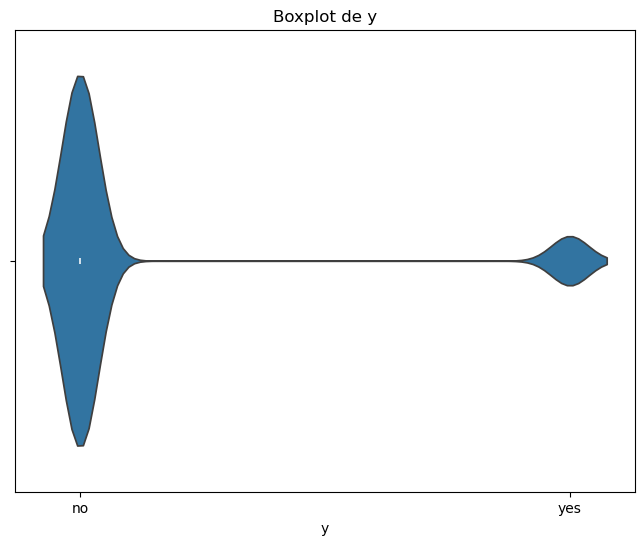

y
no     39922
yes     5289
Name: count, dtype: int64
y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64


In [41]:
plt.figure(figsize=(8,6))
sns.violinplot(x=df["y"])
plt.title("Boxplot de y")
plt.show()

# Vérifie les proportions exactes
print(df['y'].value_counts())
print(df['y'].value_counts(normalize=True) * 100)

Plus de 88% des clients n'ont pas souscrit. Ce déséquilibre est un problème majeur pour la suite car un modèle Machine Learning pourrait prédire "no" tout le temps et avoir quand même 88% de précision... sans jamais détecter un vrai "yes" !

✅ Colonnes encodées : ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']


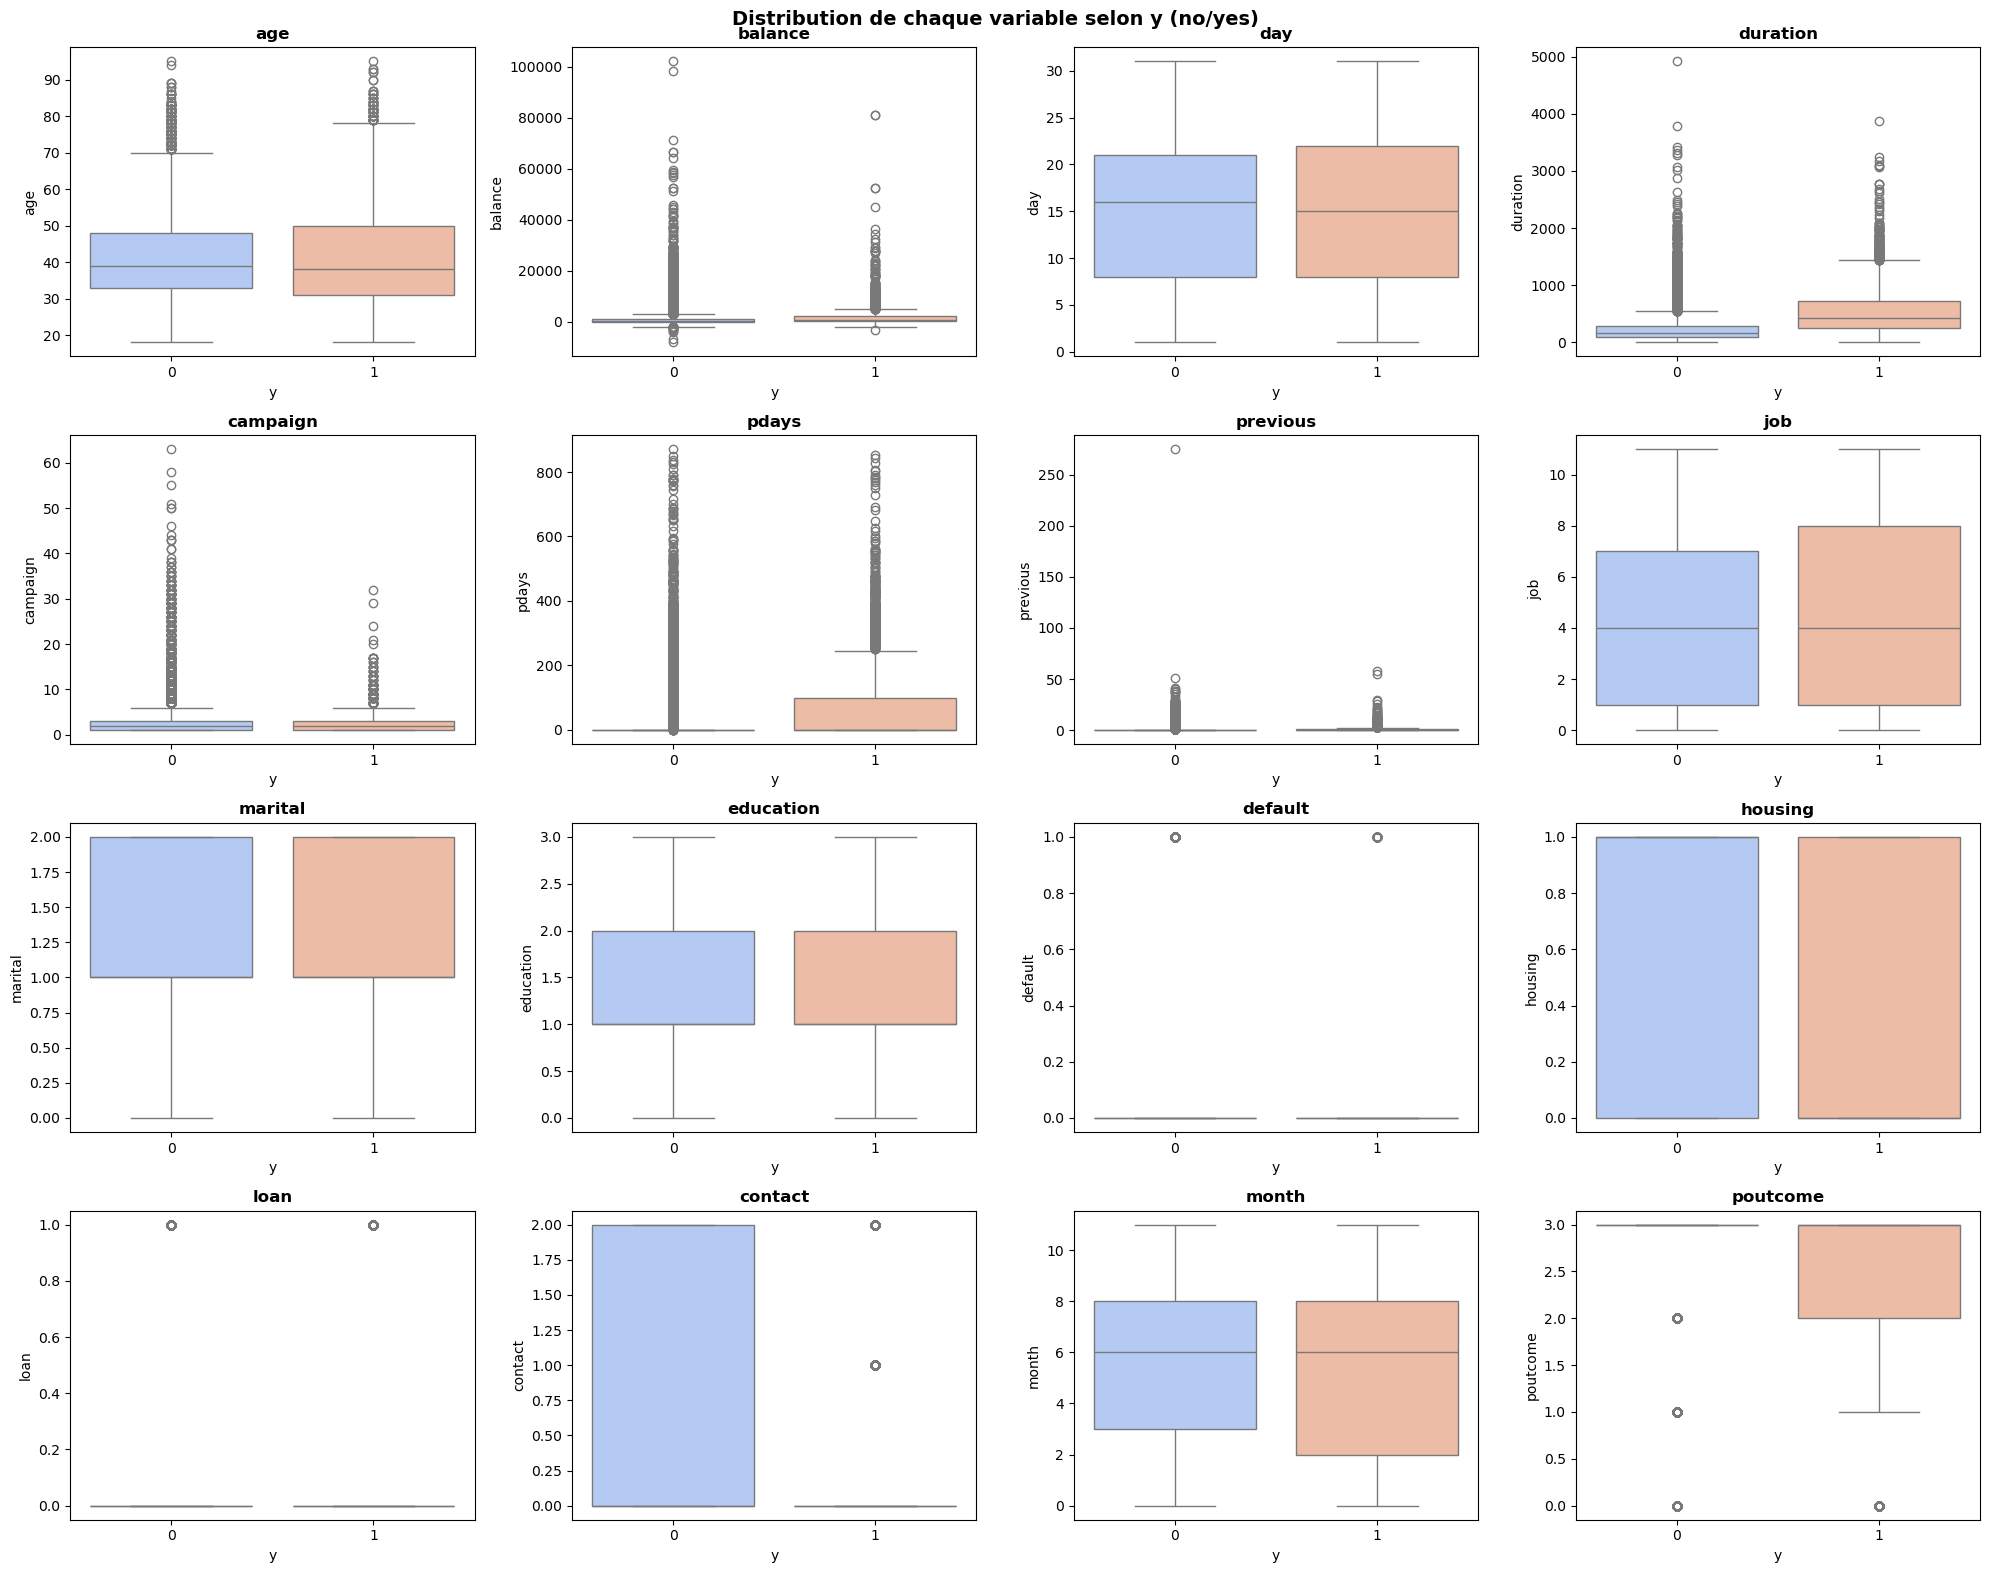

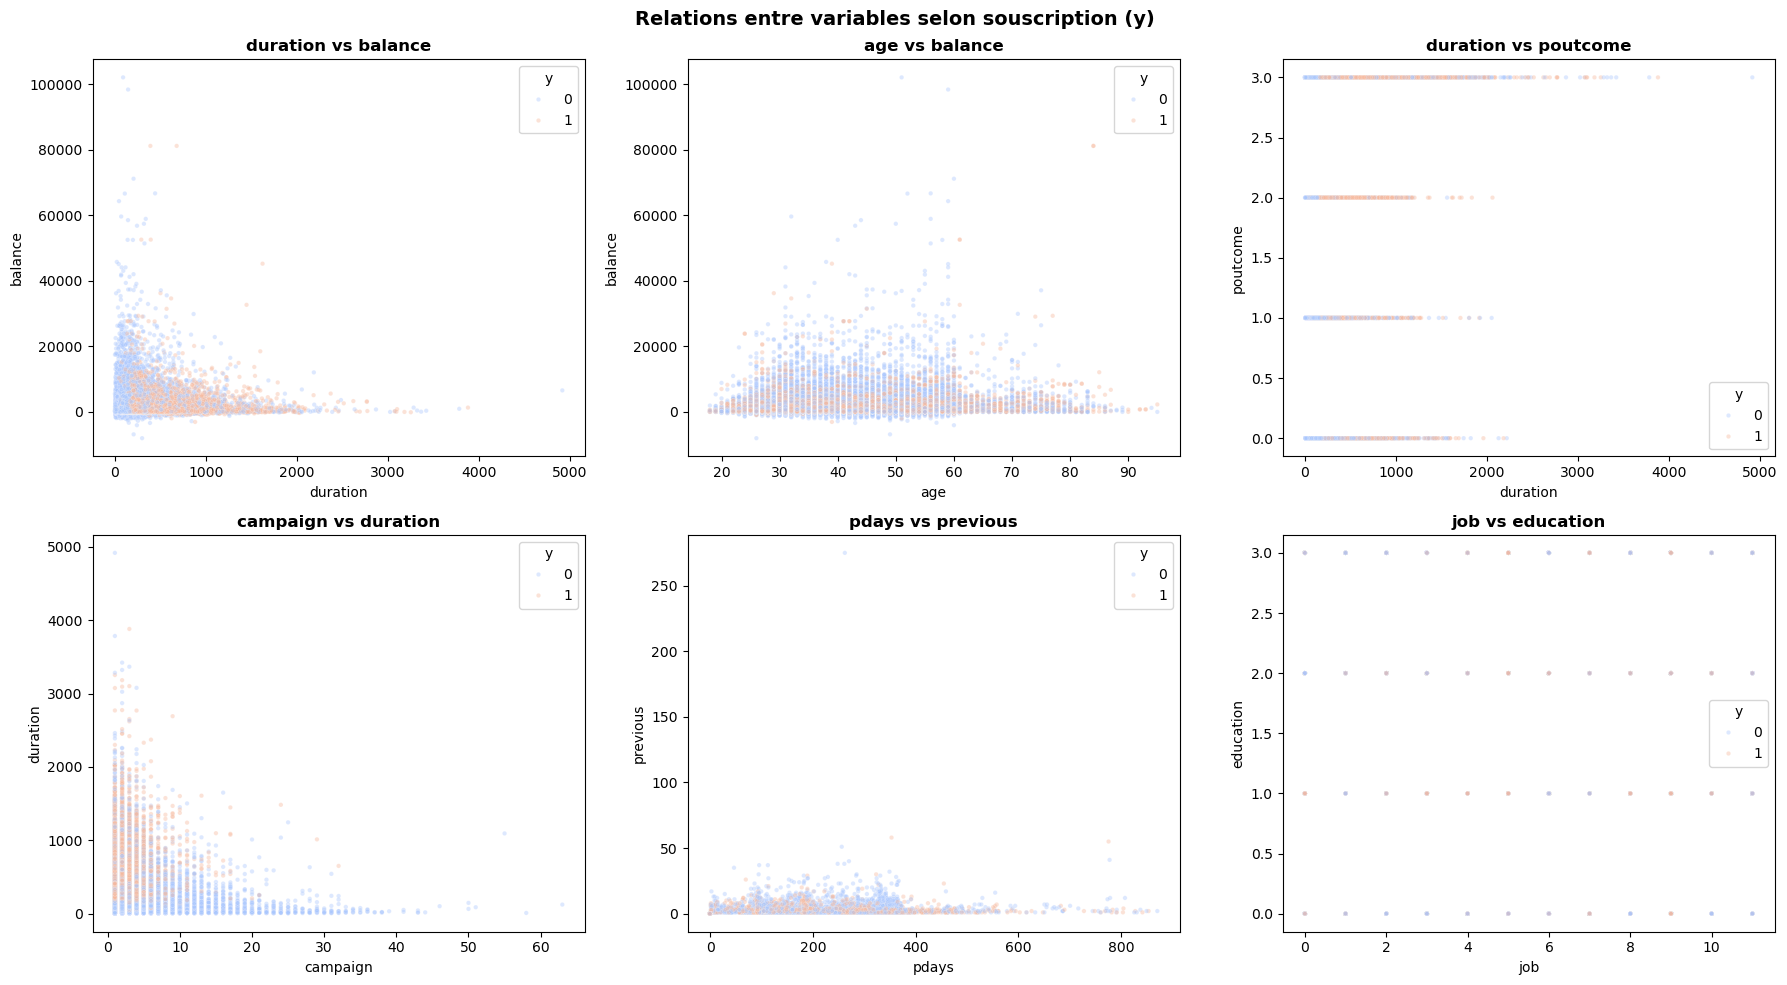

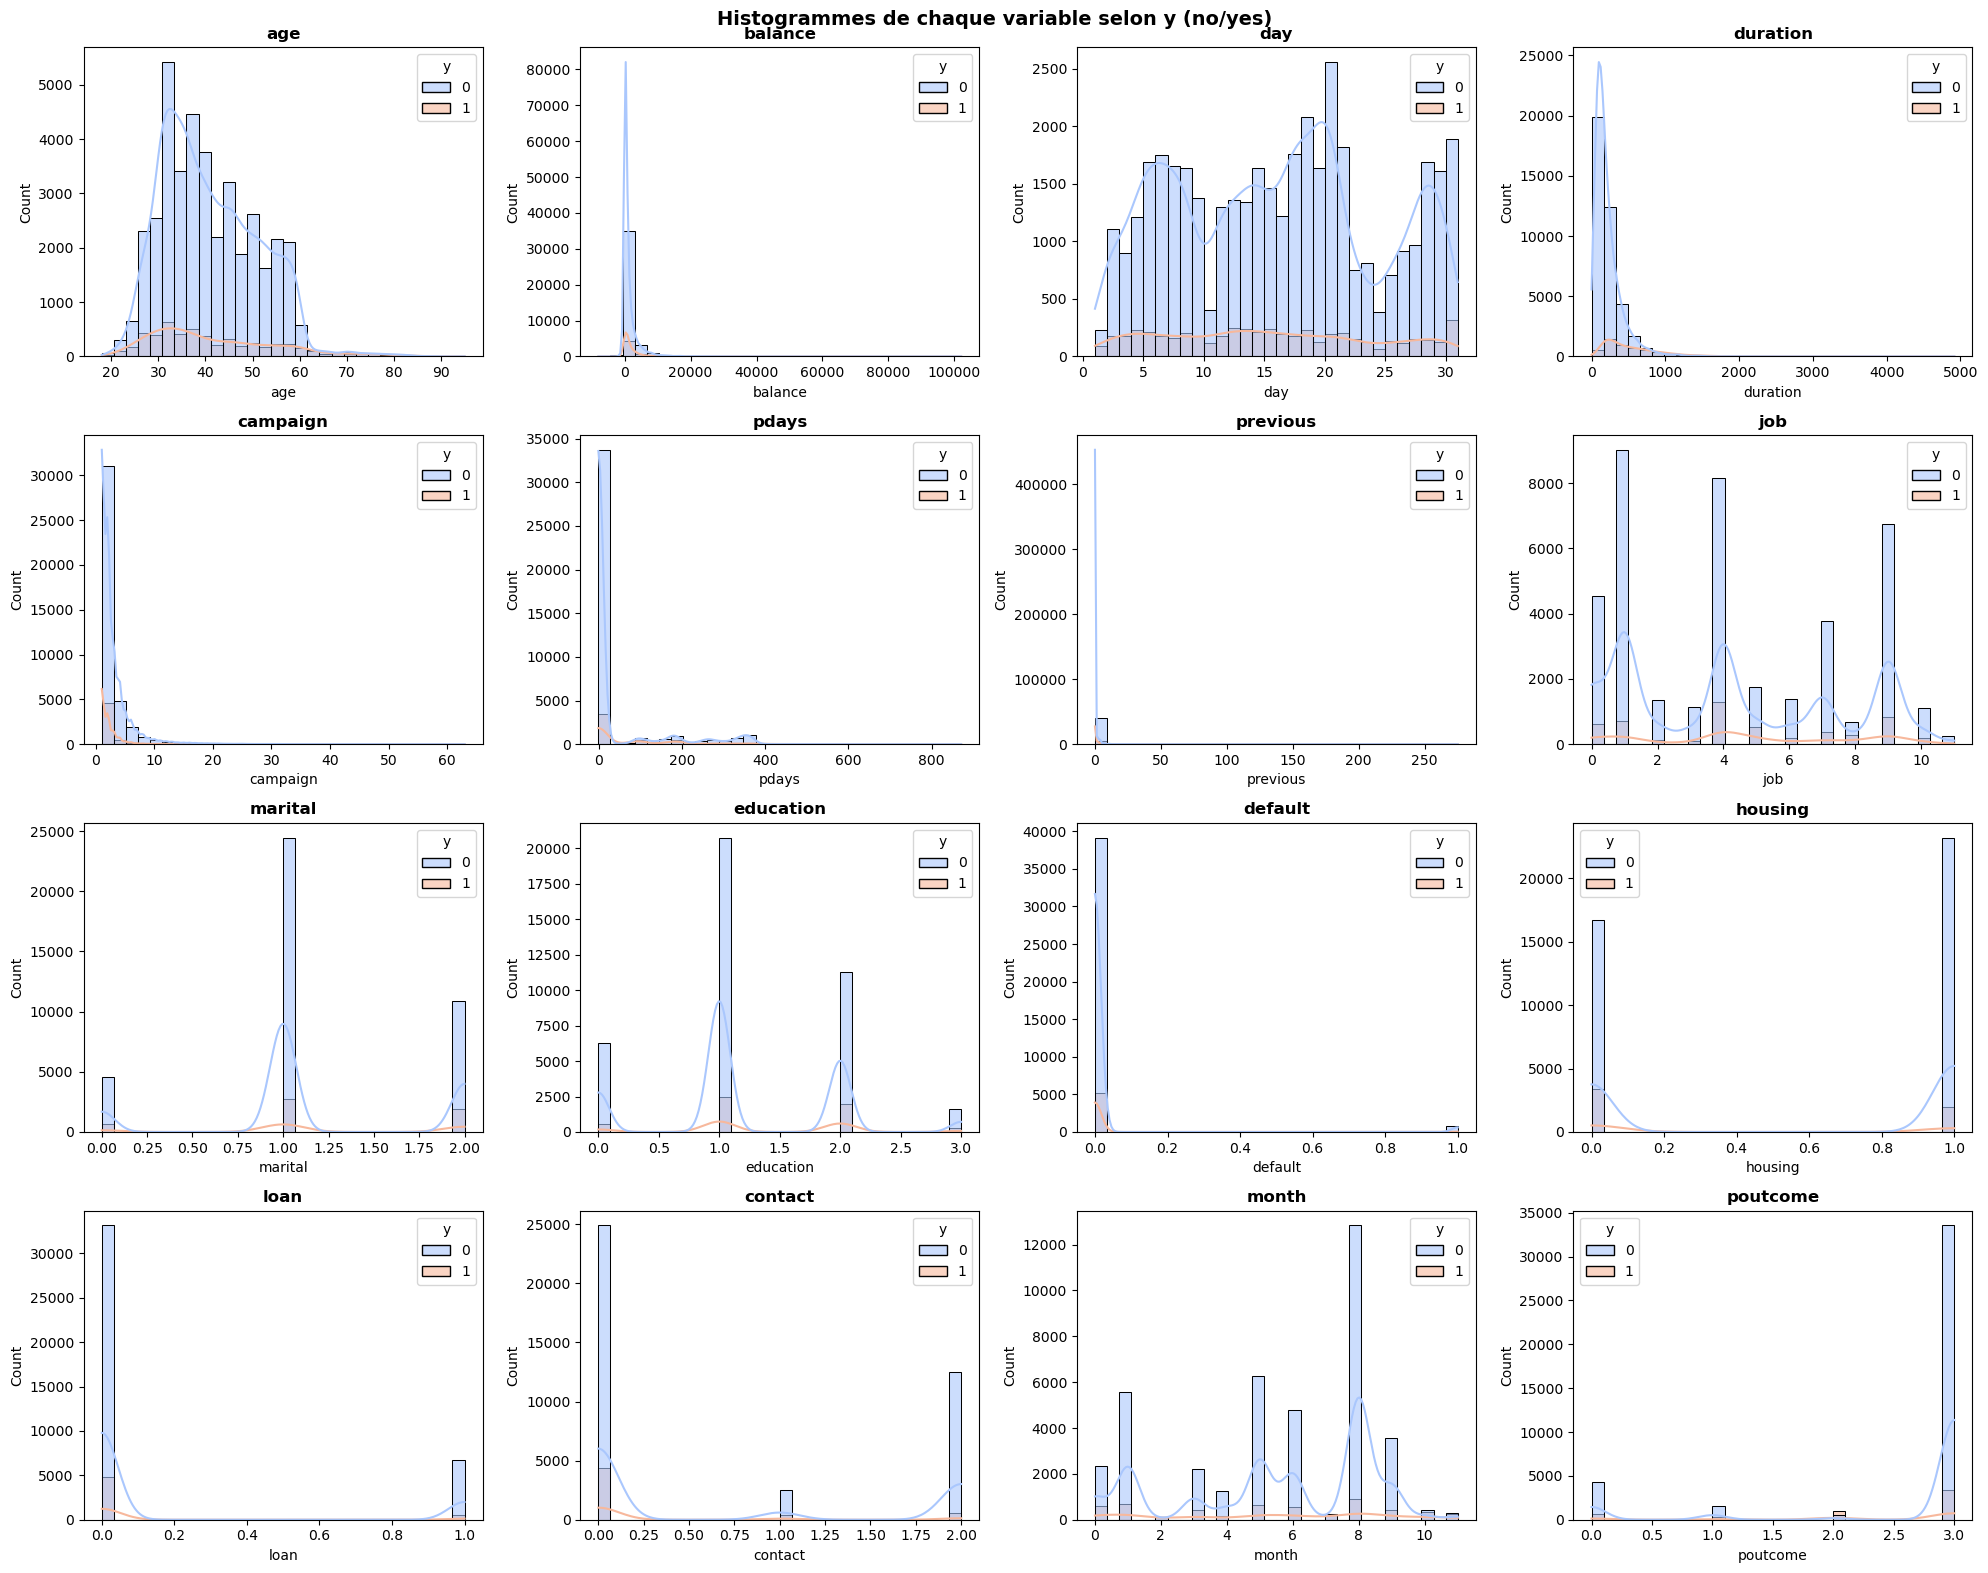

In [48]:

from sklearn.preprocessing import LabelEncoder

# Encoder toutes les variables catégorielles
df_viz = df.copy()
le = LabelEncoder()

for col in cat_cols:
    df_viz[col] = le.fit_transform(df_viz[col])

print("✅ Colonnes encodées :", cat_cols)
df_viz.head()

# Visualisation de toutes les variables vs y
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

all_cols = num_cols + [c for c in cat_cols if c != 'y']

for i, col in enumerate(all_cols):
    sns.boxplot(
        data=df_viz,
        x='y',
        y=col,
        ax=axes[i],
        palette='coolwarm'
    )
    axes[i].set_title(col, fontweight='bold')

# Cacher les axes vides
for j in range(len(all_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Distribution de chaque variable selon y (no/yes)", 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Scatter plot avec variables encodées
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

pairs = [
    ("duration", "balance"),
    ("age", "balance"),
    ("duration", "poutcome"),
    ("campaign", "duration"),
    ("pdays", "previous"),
    ("job", "education")
]

for i, (x, y) in enumerate(pairs):
    sns.scatterplot(
        data=df_viz,
        x=x,
        y=y,
        hue='y',
        alpha=0.4,
        s=10,
        ax=axes[i],
        palette='coolwarm'
    )
    axes[i].set_title(f"{x} vs {y}", fontweight='bold')

fig.suptitle("Relations entre variables selon souscription (y)", 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Histogrammes de toutes les variables encodées selon y
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

all_cols = num_cols + [c for c in cat_cols if c != 'y']

for i, col in enumerate(all_cols):
    sns.histplot(
        data=df_viz,
        x=col,
        hue='y',
        bins=30,
        kde=True,
        ax=axes[i],
        palette='coolwarm',
        alpha=0.6
    )
    axes[i].set_title(col, fontweight='bold')

# Cacher les axes vides
for j in range(len(all_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Histogrammes de chaque variable selon y (no/yes)",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Traitements des outliers

In [49]:
# Variables à clipper identifiées avec IQR
for col in ['balance', 'duration', 'campaign', 'previous']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df[col] = df[col].clip(
        lower=Q1 - 1.5 * IQR,
        upper=Q3 + 1.5 * IQR
    )
print("Outliers univariés traités")

Outliers univariés traités


In [50]:
# Isolation Forest pour les outliers multivariés
# Détecter les outliers sur toutes les variables numériques ensemble
iso = IsolationForest(contamination=0.05, random_state=42)
df['outlier'] = iso.fit_predict(df[num_cols])

print("Outliers détectés :", (df['outlier'] == -1).sum())
print("Données normales  :", (df['outlier'] == 1).sum())

# Visualiser qui sont ces outliers
df[df['outlier'] == -1][num_cols].describe()

Outliers détectés : 2261
Données normales  : 42950


,age,balance,day,duration,campaign,pdays,previous
count,2261.000000,2261.000000,2261.000000,2261.000000,2261.000000,2261.000000,2261.0
mean,47.016807,1957.807165,15.406457,342.657674,3.524547,210.006192,0.0
std,15.417513,1424.011581,9.428667,239.611591,2.023740,171.322051,0.0
min,19.000000,-1962.000000,1.000000,0.000000,1.000000,-1.000000,0.0
25%,34.000000,531.000000,7.000000,109.000000,1.000000,-1.000000,0.0
50%,46.000000,2239.000000,15.000000,318.000000,3.000000,196.000000,0.0
75%,58.000000,3462.000000,23.000000,633.000000,6.000000,344.000000,0.0
max,95.000000,3462.000000,31.000000,643.000000,6.000000,871.000000,0.0


In [51]:
# Garder les outliers mais les signaler
df['is_outlier'] = df['outlier'].map({1: 0, -1: 1})
df = df.drop(columns=['outlier'])

In [52]:
# Sauvegarder le dataset nettoyé avec les outliers signalés
df_clean = df.copy()

# Vérification avant sauvegarde
print(f"Dimensions du dataset nettoyé : {df_clean.shape}")
print(f"Nombre d'outliers signalés : {df_clean['is_outlier'].sum()}")
print(f"Données normales : {(df_clean['is_outlier'] == 0).sum()}")

# Sauvegarde
df_clean.to_csv("data/bank-full-cleaned.csv", index=False, sep=';')
print("\n Dataset sauvegardé dans data/bank-full-cleaned.csv")

Dimensions du dataset nettoyé : (45211, 19)
Nombre d'outliers signalés : 2261
Données normales : 42950

 Dataset sauvegardé dans data/bank-full-cleaned.csv
